# Longitudinal platform reach: two fixed snapshots

## tl;dr

For the same 50 Spotify IDs, every band gains followers between
**2025-09-20** and **2026-07-17**, but only
**28/50** gain monthly listeners. Median
change is **8.2%** for followers and
**2.0%** for monthly listeners; their
band-level change ranks correlate only **0.23**.
At city-catalogue level, Bristol has the largest listener increase
(**13.7%**) and Nottingham the largest decline
(**-23.5%**). Two points measure change, not a
trajectory or its cause.

## Context and methods

The longitudinal branch holds the original 50-band catalogue, city assignments
and Spotify IDs fixed, then compares the September 2025 and July 2026 captures.
It reports absolute and percentage changes for followers and rolling monthly
listeners.

### Assumptions

The two collection methods aim at the same Spotify concepts but changed from
SpotScraper to public-page extraction. Monthly listeners are rolling and can
respond to releases, tours or viral attention. With only two dates, no event
effect or stable trend is estimated.

## Data

Validate the fixed Spotify-ID panel and compute changes.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "src/python_uk_bands").exists():
    ROOT = next(
        parent for parent in Path.cwd().resolve().parents
        if (parent / "src/python_uk_bands").exists()
    )
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

ARTIFACT_DIR = ROOT / "artifacts/experiments/longitudinal_reach/20250920_20260717"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
from python_uk_bands.review_extension_experiments import (
    build_longitudinal_reach,
    plot_longitudinal_band_change,
    plot_longitudinal_city_change,
)

band_changes, city_changes, summary = build_longitudinal_reach(ROOT)

assert len(band_changes) == 50
assert band_changes["spotify_id"].is_unique
assert band_changes["city"].nunique() == 10
assert city_changes["bands"].eq(5).all()
assert (band_changes["followers_current"] >= band_changes["followers_baseline"]).all()

band_changes.to_csv(ARTIFACT_DIR / "band_snapshot_changes.csv", index=False)
city_changes.to_csv(ARTIFACT_DIR / "city_snapshot_changes.csv", index=False)
(ARTIFACT_DIR / "coverage_summary.json").write_text(
    json.dumps(summary, indent=2, sort_keys=True) + "\n"
)

display(Markdown(
    f"**{summary['bands']} fixed bands · {summary['cities']} cities · "
    f"{summary['bands_with_listener_growth']} listener gains · "
    f"{summary['bands_with_follower_growth']} follower gains**"
))

**50 fixed bands · 10 cities · 28 listener gains · 50 follower gains**

## Results

### 1. How did each fixed five-band city catalogue move?

city,bands,listeners_baseline,listeners_current,followers_baseline,followers_current,listener_change_pct,follower_change_pct
Bristol,5,"15,918,541","18,103,278","6,466,204","7,136,246",+13.7%,+10.4%
Manchester,5,"81,538,194","92,626,004","31,851,456","35,789,023",+13.6%,+12.4%
Bradford,5,"10,293,406","11,170,866","915,064","1,004,509",+8.5%,+9.8%
Liverpool,5,"47,923,901","51,268,480","33,864,772","35,922,738",+7.0%,+6.1%
Birmingham,5,"58,900,419","62,376,134","20,965,458","22,982,029",+5.9%,+9.6%
Glasgow,5,"26,073,464","26,900,505","7,946,620","8,493,626",+3.2%,+6.9%
London,5,"171,911,056","177,102,781","90,017,023","96,734,294",+3.0%,+7.5%
Sheffield,5,"83,852,220","85,695,184","46,184,664","50,737,854",+2.2%,+9.9%
Leeds,5,"18,936,316","17,946,736","6,330,866","6,625,972",-5.2%,+4.7%
Nottingham,5,"8,576,433","6,559,323","3,352,301","3,485,896",-23.5%,+4.0%


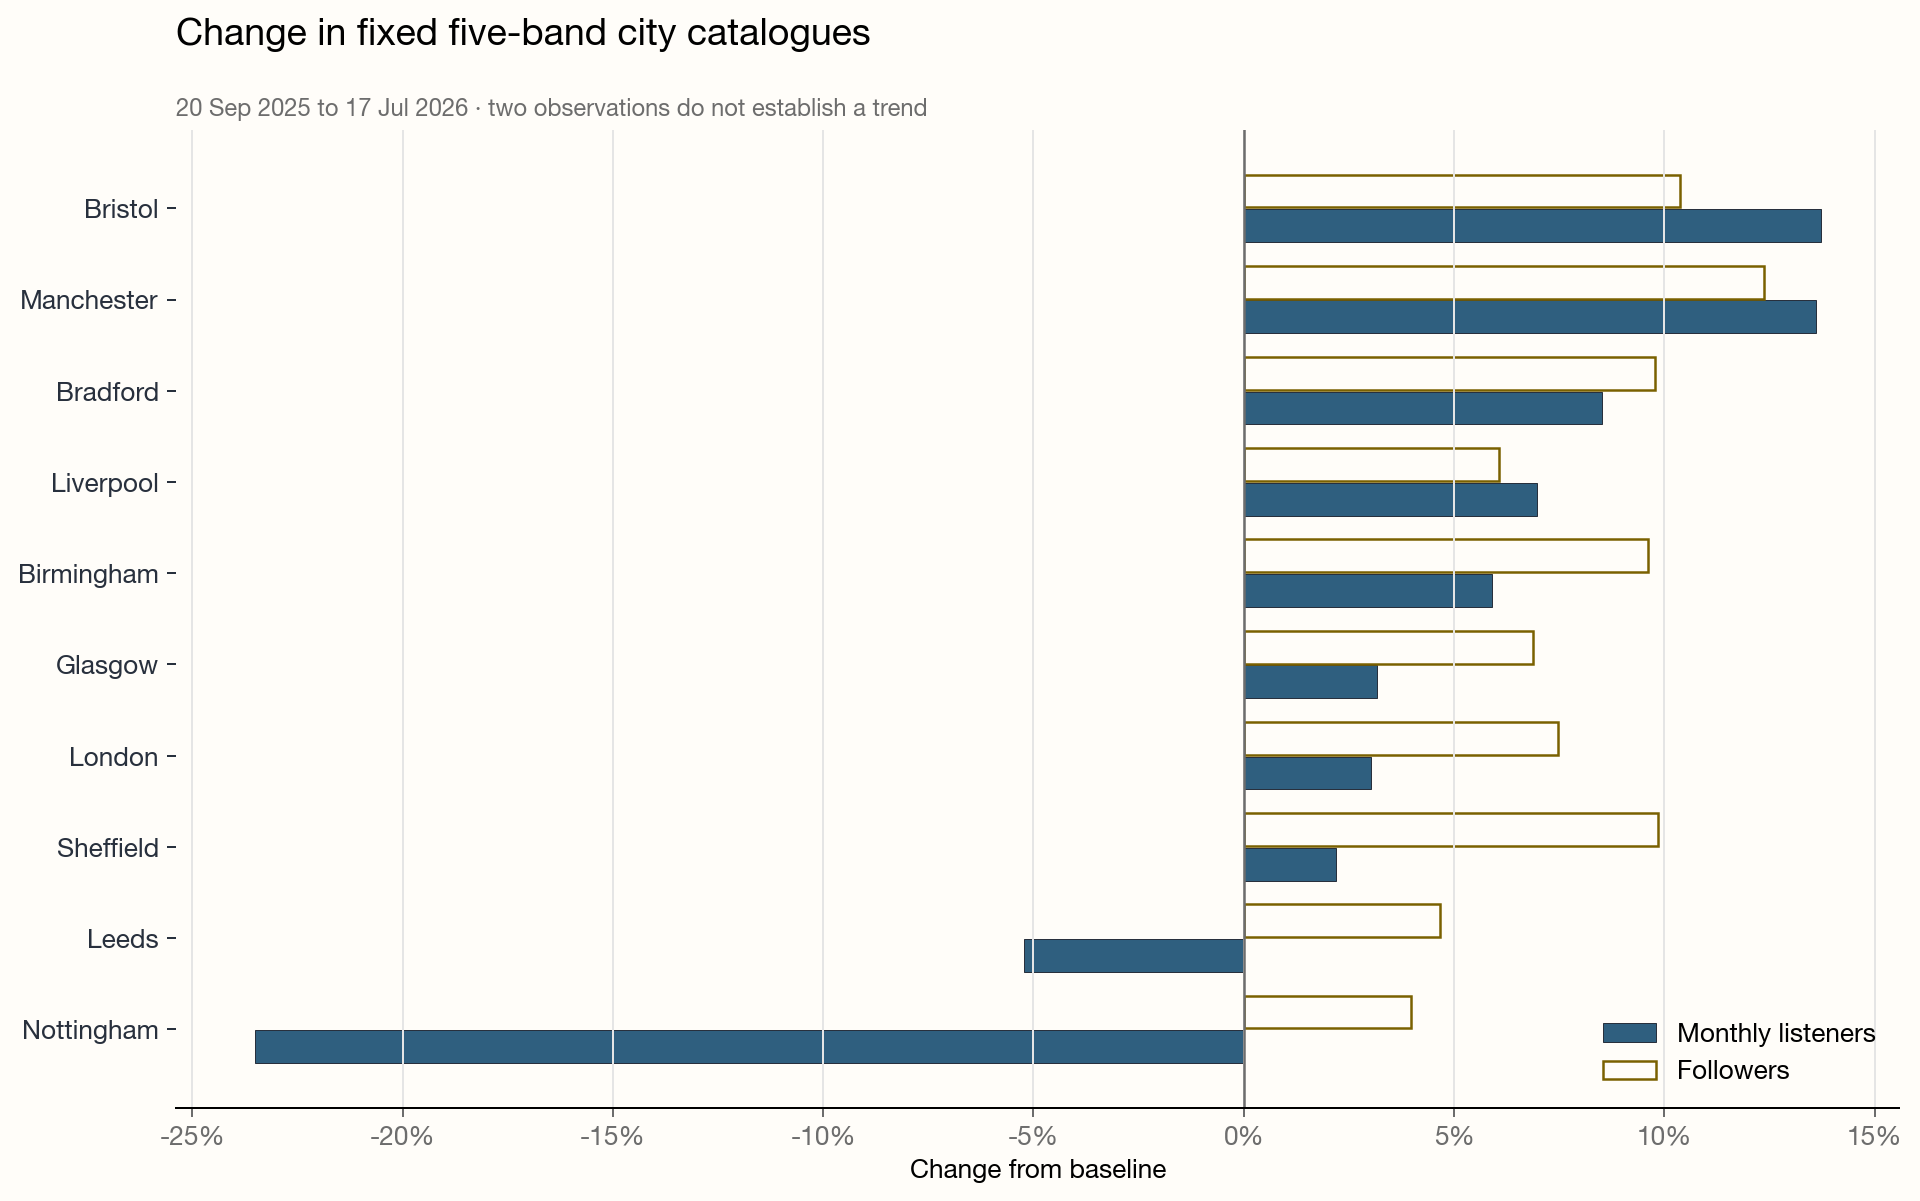

In [3]:
display(city_changes.style.hide(axis="index").format({
    "listeners_baseline": "{:,.0f}",
    "listeners_current": "{:,.0f}",
    "followers_baseline": "{:,.0f}",
    "followers_current": "{:,.0f}",
    "listener_change_pct": "{:+.1f}%",
    "follower_change_pct": "{:+.1f}%",
}))

city_path = plot_longitudinal_city_change(
    city_changes,
    output_path=ARTIFACT_DIR / "chart_01_city_change.png",
)
display(Image(filename=str(city_path)))

### 2. Do follower gains and monthly-listener changes move together?

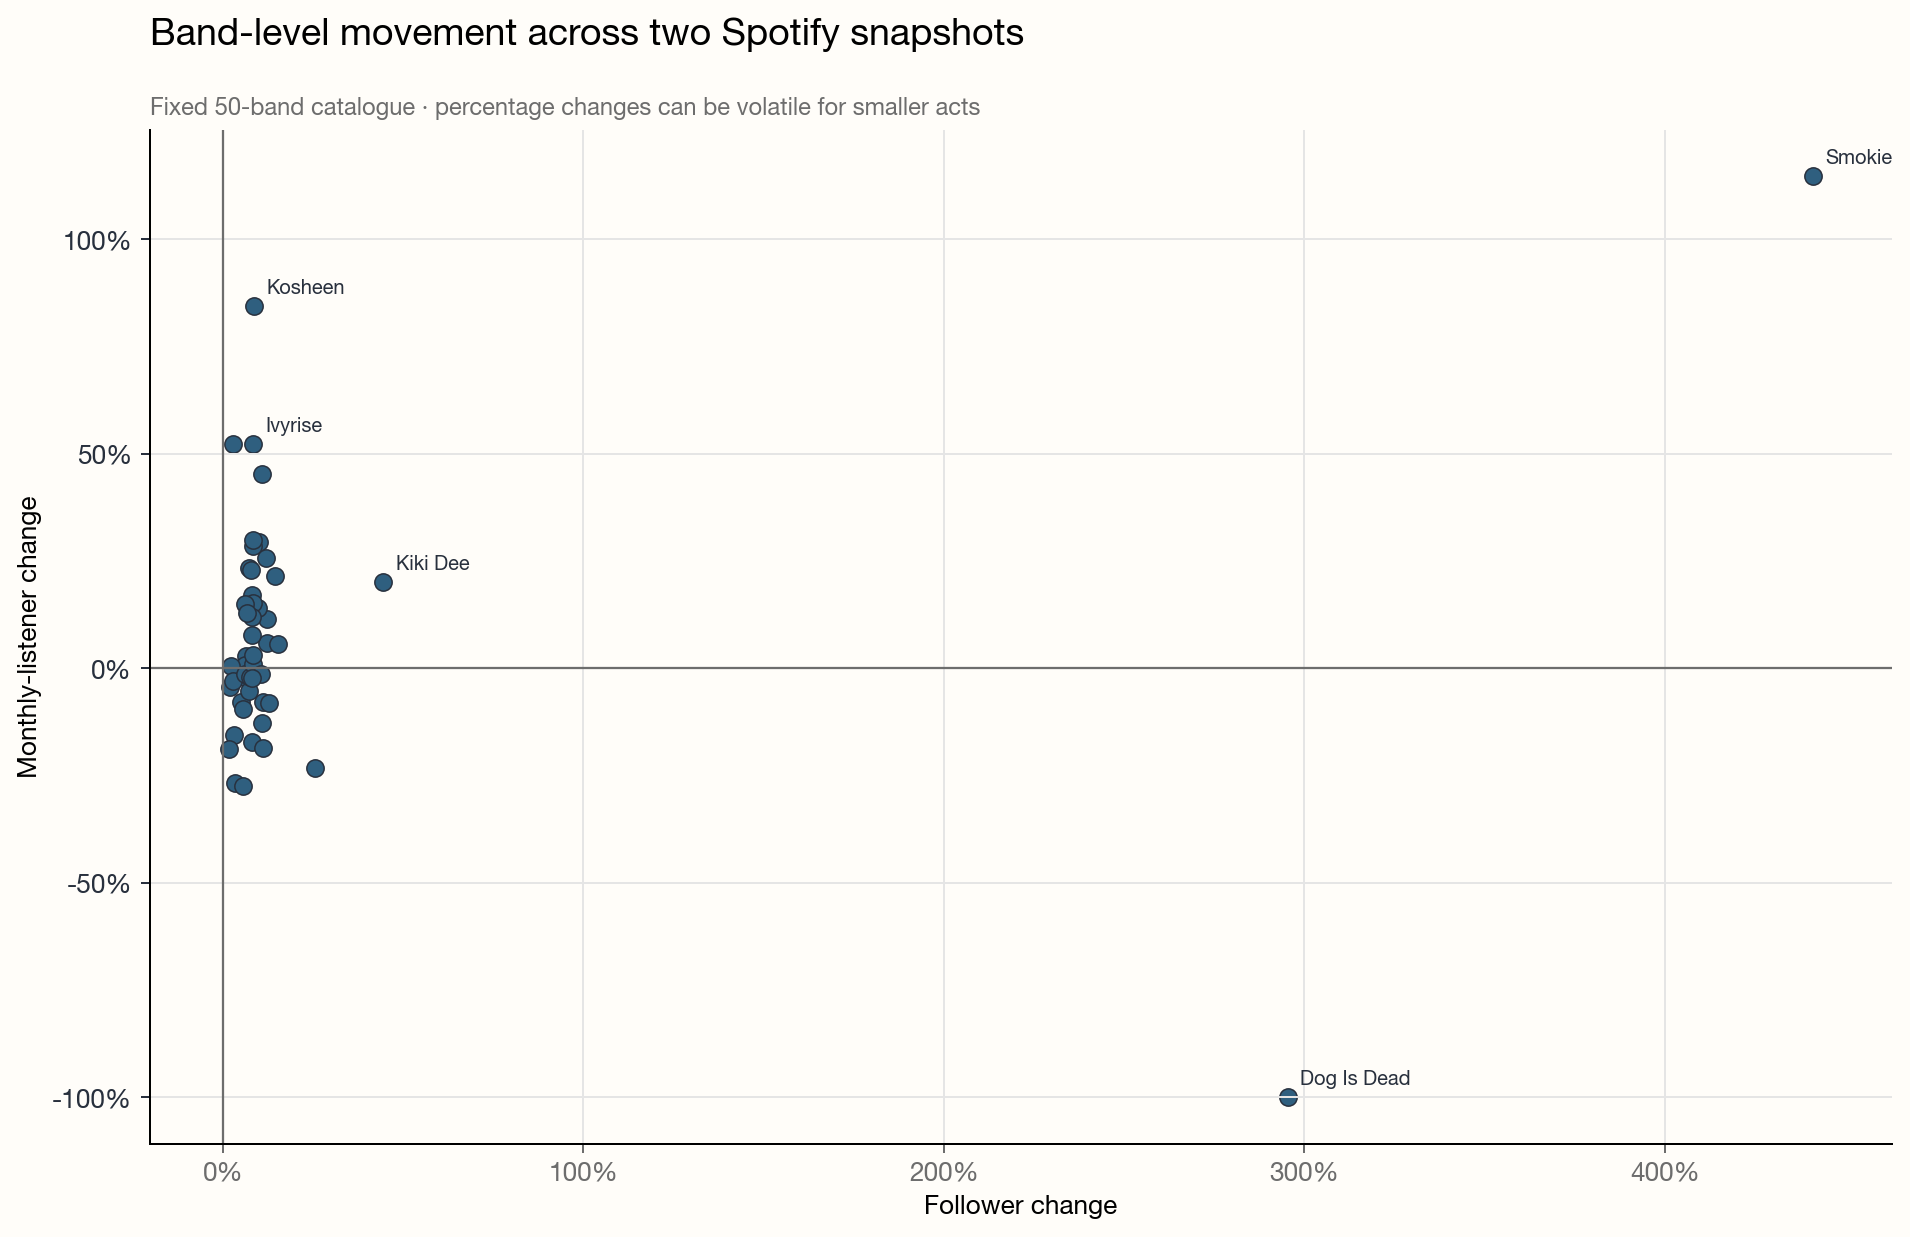

band,city,spotify_id,monthly_listeners_baseline,followers_baseline,monthly_listeners_current,followers_current,monthly_listeners_change,monthly_listeners_change_pct,followers_change,followers_change_pct
Smokie,Bradford,53K7zDzY3McLG1sAg6l2wZ,6333,34,13599,184,7266,+114.7%,150,+441.2%
Kosheen,Bristol,5squ8uM6fhMQY71t9xobJC,751064,148226,1385480,160972,634416,+84.5%,12746,+8.6%
Editors,Birmingham,6e9wIFWhBPHLE9bXK8gtBI,808289,764162,1231261,786010,422972,+52.3%,21848,+2.9%
Ivyrise,Bradford,3Cpe6aAAVacasDfOQgb3fq,40859,1795,62231,1944,21372,+52.3%,149,+8.3%
Sleaford Mods,Nottingham,0otAqZw8htTsGHfqR491Yh,231334,274788,336181,304545,104847,+45.3%,29757,+10.8%
The Stone Roses,Manchester,1lYT0A0LV5DUfxr6doRP3d,2680415,1719643,3481236,1862765,800821,+29.9%,143122,+8.3%
Blur,London,7MhMgCo0Bl0Kukl93PZbYS,10861697,3881067,14051908,4273555,3190211,+29.4%,392488,+10.1%
New Order,Manchester,0yNLKJebCb8Aueb54LYya3,6810274,2447721,8755971,2650437,1945697,+28.6%,202716,+8.3%
The Clash,London,3RGLhK1IP9jnYFH4BRFJBS,11587166,3135248,14556602,3507296,2969436,+25.6%,372048,+11.9%
ELO,Birmingham,7jefIIksOi1EazgRTfW2Pk,14861430,4425636,18346991,4747672,3485561,+23.5%,322036,+7.3%


In [4]:
band_path = plot_longitudinal_band_change(
    band_changes,
    output_path=ARTIFACT_DIR / "chart_02_band_change.png",
)
display(Image(filename=str(band_path)))

display(band_changes.sort_values(
    "monthly_listeners_change_pct", ascending=False
).style.hide(axis="index").format({
    "monthly_listeners_change_pct": "{:+.1f}%",
    "followers_change_pct": "{:+.1f}%",
}))

## Takeaways

- Followers rise monotonically in this panel, while rolling monthly listeners
  rise for only 28 of 50 bands.
- Follower growth and listener change move together only weakly. Keep them as
  separate measures.
- City aggregates can move materially even when the artist panel is fixed.
- A genuine longitudinal design needs fixed monthly captures plus release,
  tour, reissue, viral-event and membership-event annotations.